# TP1 - Fundamentos de IA
## Jogo do 15: analise experimental

Notebook baseado no `main.py`, separado em partes e com exportacao dos dados.

## Parte 1 - Imports e funcoes do projeto

In [20]:
import importlib
import subprocess
import sys
import random

def ensure_package(module_name, package_name=None):
    package = package_name or module_name
    try:
        importlib.import_module(module_name)
    except ModuleNotFoundError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', package])

ensure_package('pandas')
ensure_package('matplotlib')

import pandas as pd
import matplotlib.pyplot as plt

import main as puzzle_main
puzzle_main = importlib.reload(puzzle_main)
generate_initial_state = puzzle_main.generate_initial_state
run_all_methods = puzzle_main.run_all_methods
is_solvable = puzzle_main.is_solvable

plt.style.use('ggplot')
pd.set_option('display.max_columns', None)

## Parte 2 - Constantes do experimento (e influencia)

In [21]:
# ALGORITHMS:
#   algoritmos comparados em todos os graficos.
ALGORITHMS = ['BFS', 'DFS', 'A*']

# COLORS:
#   cores padrao para manter consistencia visual por algoritmo.
COLORS = {'BFS': '#1f77b4', 'DFS': '#ff7f0e', 'A*': '#2ca02c'}

# N_GAMES:
#   quantidade de jogos para comparar os algoritmos (ex.: 100).
#   Quanto maior, mais estaveis ficam as medias.
N_GAMES = 100

# SAMPLE_STATES:
#   tamanho da amostra de estados usada na checagem inicial.
SAMPLE_STATES = 10

# NODE_LIMIT:
#   limite maximo de nos expandidos por algoritmo em cada jogo.
#   Limite maior aumenta a chance de resolver, mas pode elevar bastante o tempo.
NODE_LIMIT = 400000

# DEPTH_LIMIT:
#   limite de profundidade da DFS.
#   Limite maior aumenta cobertura, mas pode deixar a DFS mais cara.
DEPTH_LIMIT = 100

# SEED:
#   controla a aleatoriedade. Com a mesma seed, os sorteios se repetem,
#   permitindo reproduzir os mesmos experimentos e comparar resultados com justica.
SEED = 42

random.seed(SEED)

# Aplica os limites no modulo principal para os algoritmos usarem estes valores.
puzzle_main.NODE_LIMIT = NODE_LIMIT
puzzle_main.DEPTH_LIMIT = DEPTH_LIMIT

print(
    f'N_GAMES={N_GAMES}, SAMPLE_STATES={SAMPLE_STATES}, NODE_LIMIT={NODE_LIMIT}, '
    f'DEPTH_LIMIT={DEPTH_LIMIT}, SEED={SEED}'
)

N_GAMES=100, SAMPLE_STATES=10, NODE_LIMIT=400000, DEPTH_LIMIT=100, SEED=42


## Parte 3 - Verificacao da geracao de estados aleatorios

In [22]:
def format_board(state):
    rows = []
    for i in range(0, 16, 4):
        row = []
        for value in state[i:i+4]:
            row.append(f'{value:2d}' if value != 0 else ' _')
        rows.append(' '.join(row))
    return '\n'.join(rows)

sample_states = [generate_initial_state() for _ in range(SAMPLE_STATES)]
solvable_ratio = sum(is_solvable(s) for s in sample_states) / len(sample_states)

print('Exemplo de estado inicial:')
print(format_board(sample_states[0]))
print()
print(f'Percentual solucionavel na amostra: {solvable_ratio * 100:.1f}%')
print(f'Estados distintos na amostra: {len(set(sample_states))}/{len(sample_states)}')

Exemplo de estado inicial:
 7  9  5  6
14 10 12  8
 1  2 13 15
 4 11  _  3

Percentual solucionavel na amostra: 60.0%
Estados distintos na amostra: 10/10


## Parte 4 - Execucao de N jogos (BFS, DFS e A*)

In [23]:
records = []
state_info = []

for trial in range(1, N_GAMES + 1):
    initial_state = generate_initial_state()
    solvable = is_solvable(initial_state)
    state_info.append({'trial': trial, 'solucionavel': solvable})

    results = run_all_methods(initial_state)
    for method, result in results.items():
        solved = bool(result['solved'])
        moves = len(result['moves']) if solved else None
        records.append({
            'trial': trial,
            'metodo': method,
            'estado_solucionavel': solvable,
            'resolvido': solved,
            'nos': int(result['nodes']),
            'tempo_s': float(result['time']),
            'movimentos': moves,
        })

df = pd.DataFrame(records)
df_states = pd.DataFrame(state_info)
df.head(9)

,trial,metodo,estado_solucionavel,resolvido,nos,tempo_s,movimentos
0,1,BFS,False,False,400000,1.224736,NaN
1,1,DFS,False,False,400000,0.620348,NaN
2,1,A*,False,False,400000,3.988567,NaN
3,2,BFS,False,False,400000,1.207050,NaN
4,2,DFS,False,False,400000,0.586118,NaN
5,2,A*,False,False,400000,3.946643,NaN
6,3,BFS,True,False,400000,1.185342,NaN
7,3,DFS,True,False,400000,0.579962,NaN
8,3,A*,True,False,400000,3.908064,NaN


## Parte 5 - Tabela resumo geral

In [24]:
summary = (
    df.groupby('metodo', as_index=False)
      .agg(
          total_execucoes=('resolvido', 'count'),
          resolvidos=('resolvido', 'sum'),
          media_nos=('nos', 'mean'),
          media_tempo_s=('tempo_s', 'mean'),
          media_movimentos=('movimentos', 'mean'),
      )
)
summary['taxa_sucesso_%'] = (summary['resolvidos'] / summary['total_execucoes']) * 100
summary = summary.sort_values('metodo').reset_index(drop=True)
summary

,metodo,total_execucoes,resolvidos,media_nos,media_tempo_s,media_movimentos,taxa_sucesso_%
0,A*,100,2,393168.9,3.904532,43.5,2.0
1,BFS,100,0,400000.0,1.179788,NaN,0.0
2,DFS,100,0,400000.0,0.598123,NaN,0.0


## Parte 6 - Grafico: media de nos expandidos

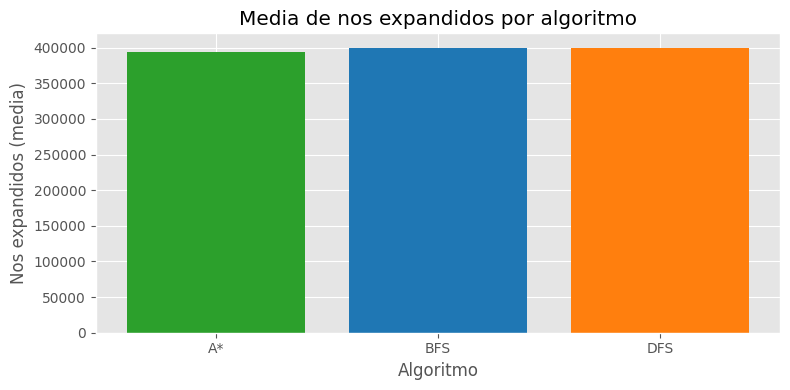

In [25]:
plt.figure(figsize=(8, 4))
bar_colors = [COLORS[m] for m in summary['metodo']]
plt.bar(summary['metodo'], summary['media_nos'], color=bar_colors)
plt.title('Media de nos expandidos por algoritmo')
plt.xlabel('Algoritmo')
plt.ylabel('Nos expandidos (media)')
plt.tight_layout()
plt.show()

## Parte 7 - Grafico: media de tempo

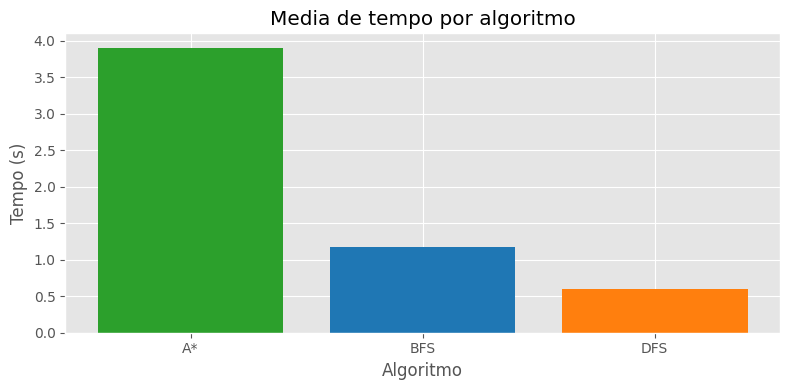

In [26]:
plt.figure(figsize=(8, 4))
bar_colors = [COLORS[m] for m in summary['metodo']]
plt.bar(summary['metodo'], summary['media_tempo_s'], color=bar_colors)
plt.title('Media de tempo por algoritmo')
plt.xlabel('Algoritmo')
plt.ylabel('Tempo (s)')
plt.tight_layout()
plt.show()

## Parte 8 - Grafico: taxa de sucesso

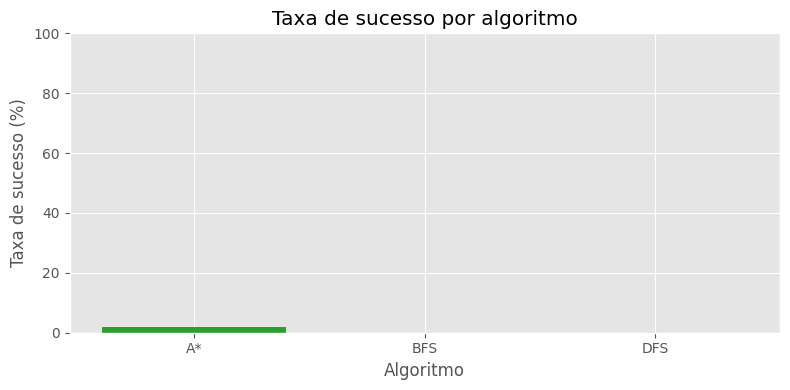

In [27]:
plt.figure(figsize=(8, 4))
bar_colors = [COLORS[m] for m in summary['metodo']]
plt.bar(summary['metodo'], summary['taxa_sucesso_%'], color=bar_colors)
plt.ylim(0, 100)
plt.title('Taxa de sucesso por algoritmo')
plt.xlabel('Algoritmo')
plt.ylabel('Taxa de sucesso (%)')
plt.tight_layout()
plt.show()

## Parte 9 - Grafico: nos expandidos por sequencia

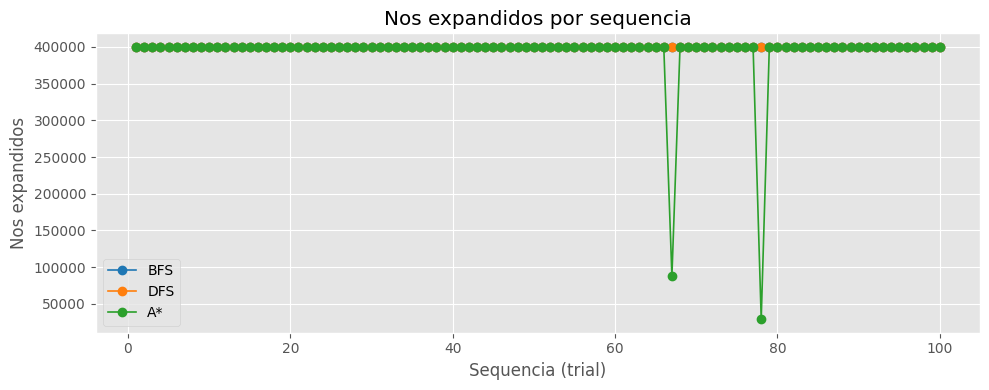

In [28]:
plt.figure(figsize=(10, 4))
for method in ALGORITHMS:
    subset = df[df['metodo'] == method].sort_values('trial')
    plt.plot(subset['trial'], subset['nos'], marker='o', linewidth=1.2, label=method, color=COLORS[method])

plt.title('Nos expandidos por sequencia')
plt.xlabel('Sequencia (trial)')
plt.ylabel('Nos expandidos')
plt.legend()
plt.tight_layout()
plt.show()

## Parte 10 - Grafico pedido: movimentos por sequencia (linha por algoritmo + ponto por sequencia)

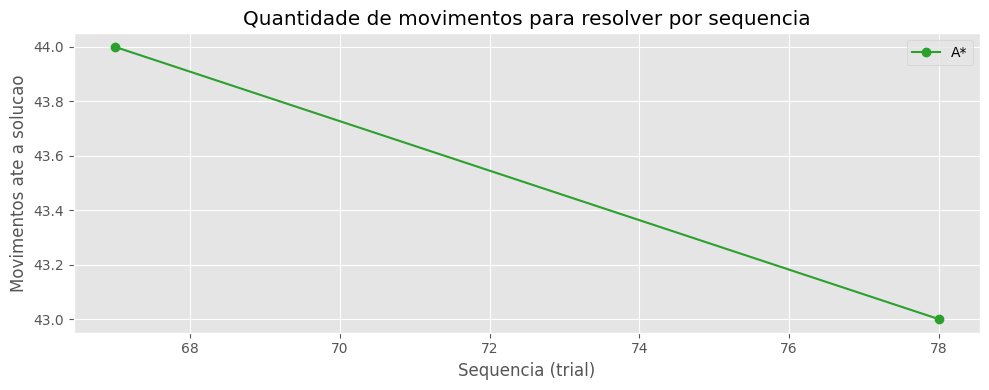

Arquivo salvo: movimentos_por_sequencia.csv


metodo,A*
trial,
67,44.0
78,43.0


In [29]:
mov_by_trial = df.pivot_table(index='trial', columns='metodo', values='movimentos', aggfunc='first')
mov_by_trial.to_csv('movimentos_por_sequencia.csv')

plt.figure(figsize=(10, 4))
plotted = False
for method in ALGORITHMS:
    if method in mov_by_trial.columns:
        series = mov_by_trial[method].dropna()
        if not series.empty:
            plt.plot(series.index, series.values, marker='o', linewidth=1.5, label=method, color=COLORS[method])
            plotted = True

plt.title('Quantidade de movimentos para resolver por sequencia')
plt.xlabel('Sequencia (trial)')
plt.ylabel('Movimentos ate a solucao')
if plotted:
    plt.legend()
else:
    plt.text(0.5, 0.5, 'Nenhuma solucao encontrada nesta rodada', ha='center', va='center', transform=plt.gca().transAxes)
plt.tight_layout()
plt.show()

print('Arquivo salvo: movimentos_por_sequencia.csv')
mov_by_trial.head(10)

## Parte 11 - Regra mapeada: solucionabilidade dos estados iniciais

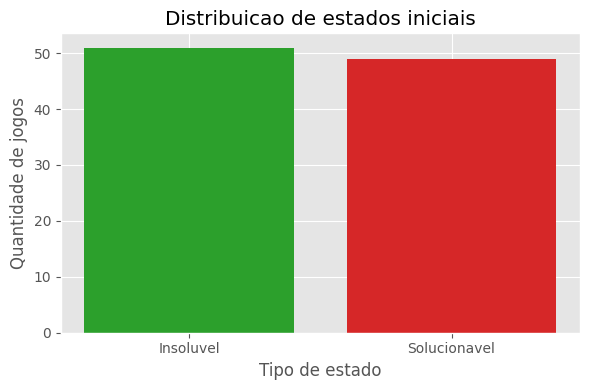

solucionavel
Insoluvel       51
Solucionavel    49
Name: count, dtype: int64

In [30]:
solvability_counts = (
    df_states['solucionavel']
    .value_counts()
    .rename(index={True: 'Solucionavel', False: 'Insoluvel'})
)

plt.figure(figsize=(6, 4))
plt.bar(solvability_counts.index, solvability_counts.values, color=['#2ca02c', '#d62728'])
plt.title('Distribuicao de estados iniciais')
plt.xlabel('Tipo de estado')
plt.ylabel('Quantidade de jogos')
plt.tight_layout()
plt.show()

solvability_counts

## Parte 12 - Regra mapeada: desempenho por solucionabilidade

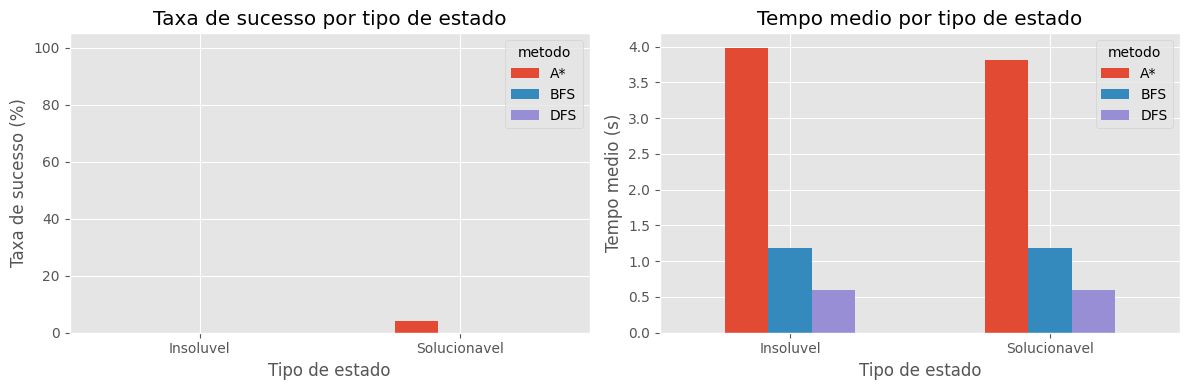

Arquivo salvo: resumo_solucionabilidade.csv


,estado_solucionavel,metodo,taxa_sucesso,media_nos,media_tempo,taxa_sucesso_%,tipo_estado
0,False,A*,0.000000,400000.000000,3.988096,0.000000,Insoluvel
1,False,BFS,0.000000,400000.000000,1.180300,0.000000,Insoluvel
2,False,DFS,0.000000,400000.000000,0.599041,0.000000,Insoluvel
3,True,A*,0.040816,386058.979592,3.817557,4.081633,Solucionavel
4,True,BFS,0.000000,400000.000000,1.179256,0.000000,Solucionavel
5,True,DFS,0.000000,400000.000000,0.597167,0.000000,Solucionavel


In [31]:
by_solvability = (
    df.groupby(['estado_solucionavel', 'metodo'], as_index=False)
      .agg(
          taxa_sucesso=('resolvido', 'mean'),
          media_nos=('nos', 'mean'),
          media_tempo=('tempo_s', 'mean'),
      )
)
by_solvability['taxa_sucesso_%'] = by_solvability['taxa_sucesso'] * 100
by_solvability['tipo_estado'] = by_solvability['estado_solucionavel'].map({True: 'Solucionavel', False: 'Insoluvel'})

pivot_success = by_solvability.pivot(index='tipo_estado', columns='metodo', values='taxa_sucesso_%')
pivot_time = by_solvability.pivot(index='tipo_estado', columns='metodo', values='media_tempo')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

pivot_success.plot(kind='bar', ax=axes[0], rot=0)
axes[0].set_title('Taxa de sucesso por tipo de estado')
axes[0].set_xlabel('Tipo de estado')
axes[0].set_ylabel('Taxa de sucesso (%)')
axes[0].set_ylim(0, 105)

pivot_time.plot(kind='bar', ax=axes[1], rot=0)
axes[1].set_title('Tempo medio por tipo de estado')
axes[1].set_xlabel('Tipo de estado')
axes[1].set_ylabel('Tempo medio (s)')

plt.tight_layout()
plt.show()

by_solvability.to_csv('resumo_solucionabilidade.csv', index=False)
print('Arquivo salvo: resumo_solucionabilidade.csv')
by_solvability

## Parte 13 - Regra mapeada: eficiencia (nos por movimento)

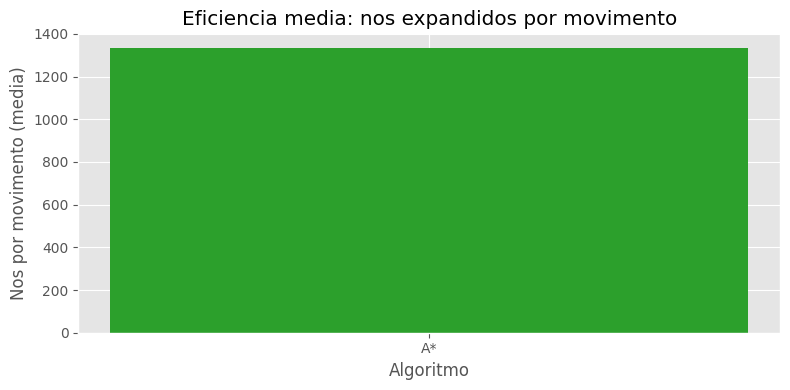

Arquivo salvo: eficiencia_algoritmos.csv


,metodo,media_nos_por_movimento,mediana_nos_por_movimento
0,A*,1335.989958,1335.989958


In [32]:
df_solved = df[df['resolvido']].copy()
if df_solved.empty:
    print('Nenhuma solucao encontrada; nao foi possivel calcular eficiencia por movimento.')
    efficiency_summary = pd.DataFrame(columns=['metodo', 'media_nos_por_movimento', 'mediana_nos_por_movimento'])
else:
    df_solved['nos_por_movimento'] = df_solved['nos'] / df_solved['movimentos']
    efficiency_summary = (
        df_solved.groupby('metodo', as_index=False)
          .agg(
              media_nos_por_movimento=('nos_por_movimento', 'mean'),
              mediana_nos_por_movimento=('nos_por_movimento', 'median'),
          )
    )

    plt.figure(figsize=(8, 4))
    bar_colors = [COLORS[m] for m in efficiency_summary['metodo']]
    plt.bar(
        efficiency_summary['metodo'],
        efficiency_summary['media_nos_por_movimento'],
        color=bar_colors
    )
    plt.title('Eficiencia media: nos expandidos por movimento')
    plt.xlabel('Algoritmo')
    plt.ylabel('Nos por movimento (media)')
    plt.tight_layout()
    plt.show()

efficiency_summary.to_csv('eficiencia_algoritmos.csv', index=False)
print('Arquivo salvo: eficiencia_algoritmos.csv')
efficiency_summary

## Parte 14 - Grafico adicional: distribuicao de tempo por algoritmo (boxplot)

/tmp/ipykernel_13695/1161821290.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=ALGORITHMS)


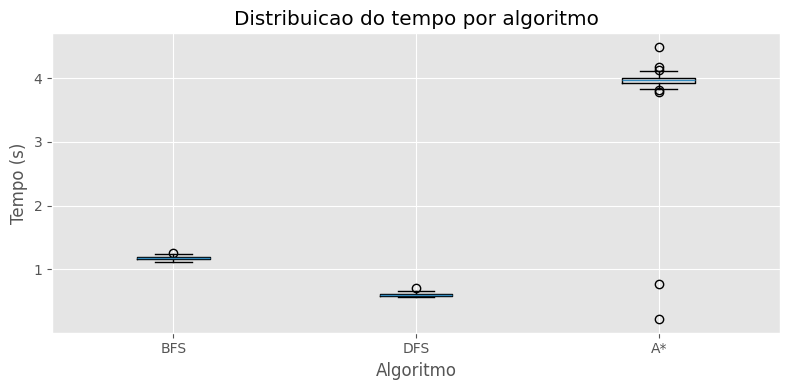

In [33]:
plt.figure(figsize=(8, 4))
data = [df[df['metodo'] == method]['tempo_s'] for method in ALGORITHMS]
plt.boxplot(data, labels=ALGORITHMS)
plt.title('Distribuicao do tempo por algoritmo')
plt.xlabel('Algoritmo')
plt.ylabel('Tempo (s)')
plt.tight_layout()
plt.show()

## Parte 15 - Dados adicionais e exportacao final

In [34]:
best_nodes = summary.loc[summary['media_nos'].idxmin(), 'metodo']
best_time = summary.loc[summary['media_tempo_s'].idxmin(), 'metodo']
best_success = summary.loc[summary['taxa_sucesso_%'].idxmax(), 'metodo']

print(f'Melhor media de nos: {best_nodes}')
print(f'Melhor media de tempo: {best_time}')
print(f'Melhor taxa de sucesso: {best_success}')

df.to_csv('resultados_execucoes_tp1.csv', index=False)
summary.to_csv('resumo_geral_algoritmos.csv', index=False)
print('Arquivos salvos: resultados_execucoes_tp1.csv e resumo_geral_algoritmos.csv')
summary

Melhor media de nos: A*
Melhor media de tempo: DFS
Melhor taxa de sucesso: A*
Arquivos salvos: resultados_execucoes_tp1.csv e resumo_geral_algoritmos.csv


,metodo,total_execucoes,resolvidos,media_nos,media_tempo_s,media_movimentos,taxa_sucesso_%
0,A*,100,2,393168.9,3.904532,43.5,2.0
1,BFS,100,0,400000.0,1.179788,NaN,0.0
2,DFS,100,0,400000.0,0.598123,NaN,0.0
